# Etapa 2: Estimacao de Efeito Causal via Double Machine Learning

**Objetivo:** Estimar o impacto causal da liquidez extraordinaria do comprador (`D`) sobre o premio de reinvestimento (`Y`), neutralizando confundidores estruturais de alta dimensao via Double ML (Chernozhukov et al., 2018).

**Dados:** `output/transfers_etapa2_ready.csv`: 5.146 transferencias, 53 colunas (inclui `premio_reinvestimento` da Etapa 1).

## Pipeline

| Secao | Descricao |
|-------|-----------|
| 0. Setup | Imports, instalacao do EconML, sanity check |
| 1. Feature Engineering | D = log_revenue, Y winsorizado, imputacao por season, selecao de confundidores |
| 2. LinearDML -- ATE | Efeito causal medio com cross-fitting de 5 folds |
| 3. Validacao | Testes de placebo, R2 first-stage, grafico de residuos |
| 4. CausalForestDML -- CATE | Heterogeneidade do efeito causal |
| 5. IVB | Indice de Vulnerabilidade de Barganha por clube |
| 6. Decaimento entre temporadas | Theta_0 por ano (2023/2024/2025) |
| 7. Limitacoes | Advertencias metodologicas |
| 8. Exportacao | Resultados para relatorio final |

---
**Membros**
> Carlos Ferreira dos Santos Junior - 2019054412

> Cesar de Paulo Moraes

> Leticia Ribeiro Miranda - 2021095686

> Lucas Ferreira Pedras - 2021030835

> Lucca ALvarenga de Magalhaes Pinto - 2021036736

## 0. Setup

In [1]:
# econml NAO e necessario aqui: este notebook foi portado para Double ML *manual*
# (ver celula de setup). Linha original mantida como referencia ao desenho com econml.
# !pip install econml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

warnings.filterwarnings('ignore')

# NOTA DE PORTABILIDADE
# Este notebook foi portado para Double ML *manual* porque o econml nao instala no
# ambiente atual (Python 3.14 + NumPy 2.4). A implementacao abaixo segue Robinson
# (partialling-out) com cross-fitting K-fold e erro-padrao robusto HC1, e reproduz
# o ATE que o econml.LinearDML produzia. O CATE usa o R-learner (Nie & Wager) no
# lugar do CausalForestDML (aproximacao; ver knowledge/reprocessamento_8temporadas.md).

RF = lambda n, d, s: RandomForestRegressor(n_estimators=n, max_depth=d, random_state=s, n_jobs=-1)
SEED = 42
np.random.seed(SEED)


def dml_partial_linear(Y, D, W, seed=SEED, K=5):
    """Double ML parcialmente linear: cross-fitting K-fold + partialling-out, SE HC1."""
    Y = np.asarray(Y, float); D = np.asarray(D, float); W = np.asarray(W, float)
    n = len(Y); y_hat = np.zeros(n); d_hat = np.zeros(n)
    for tr, te in KFold(n_splits=K, shuffle=True, random_state=seed).split(W):
        y_hat[te] = RF(200, 5, seed).fit(W[tr], Y[tr]).predict(W[te])
        d_hat[te] = RF(200, 5, seed).fit(W[tr], D[tr]).predict(W[te])
    y_res = Y - y_hat; d_res = D - d_hat
    X = np.column_stack([np.ones(n), d_res]); inv = np.linalg.inv(X.T @ X)
    b = inv @ (X.T @ y_res); resid = y_res - X @ b
    S_ = X * resid[:, None]; cov = inv @ (S_.T @ S_) @ inv * (n / (n - 2))
    theta = b[1]; se = np.sqrt(cov[1, 1])
    return {'theta': theta, 'ci': (theta - 1.96*se, theta + 1.96*se), 'se': se,
            'y_res': y_res, 'd_res': d_res,
            'r2_y': r2_score(Y, y_hat), 'r2_t': r2_score(D, d_hat)}


def rlearner_cate(Y, D, W, seed=SEED, K=5):
    """CATE via R-learner (Nie & Wager): RF sobre z = Y_res/D_res ponderado por D_res^2."""
    fit = dml_partial_linear(Y, D, W, seed, K)
    yr, dr = fit['y_res'], fit['d_res']
    mask = np.abs(dr) > 1e-6
    z = np.where(mask, yr / np.where(mask, dr, 1.0), 0.0); w = dr ** 2
    forest = RF(300, 5, seed)
    forest.fit(W[mask], z[mask], sample_weight=w[mask])
    return forest.predict(W)

print('Imports OK (Double ML manual)')

Imports OK (Double ML manual)


## 1. Feature Engineering

### Tratamento D -- log_revenue
Usamos `log_revenue` (ja calculado como `log1p(revenue_sales)`). O +1 resolve o problema de 73 observacoes com receita zero. O coeficiente theta_0 sera interpretado como **elasticidade**.

**Nota:** D reflete o total de vendas na janela inteira.

### Winsorizacao de Y
Winsorizamos Y no p1 (-1,64) e p99 (1,45) para robustez contra outliers (~42 obs). D ja tem cauda inferior natural em zero (p1=0), nao winsorizado.

### Imputacao por Temporada
`squad_size`, `average_age`, `national_team_players`: 710 nulos (706 em 2025). Imputados pela **mediana dentro de cada `season_id`**.

### Confundidores (W)
Incluimos apenas variaveis **pre-tratamento**. Excluimos mediadores e `log_mv` (Y ja residualizado na Etapa 1).

**Armadilha da dummy:** `season_2023` omitida (base).

| Categoria | Variaveis | Justificativa |
|-----------|-----------|---------------|
| Rede estrutural | `in_degree`, `out_degree`, `pagerank` | Posicao do clube na rede |
| Porte do clube | `squad_size`, `average_age`, `national_team_players` | Proxy de poder financeiro |
| Safra | `season_2024`, `season_2025` | Inflacao de mercado (base: 2023) |
| Liga | 6 dummies de competition_code | Poder economico da liga |

### 1.1 Carregamento e Analise Inicial

In [3]:
df = pd.read_csv('../output/transfers_etapa2_ready.csv')
print(f'Shape: {df.shape}')
print()
print('Y -- premio_reinvestimento:')
print(df['premio_reinvestimento'].describe().round(4))
print()
print('D -- log_revenue:')
print(df['log_revenue'].describe().round(4))
zeros = (df['revenue_sales'] == 0).sum()
print(f'\nObservacoes com revenue_sales == 0: {zeros} (todas do Paris FC)')

Shape: (5146, 53)

Y -- premio_reinvestimento:
count    5146.0000
mean       -0.0141
std         0.5865
min        -4.5042
25%        -0.3367
50%         0.0193
75%         0.3324
max         2.2621
Name: premio_reinvestimento, dtype: float64

D -- log_revenue:
count    5146.0000
mean       16.3755
std         3.8017
min         0.0000
25%        16.2794
50%        17.2559
75%        18.0936
max        19.7047
Name: log_revenue, dtype: float64

Observacoes com revenue_sales == 0: 231 (todas do Paris FC)


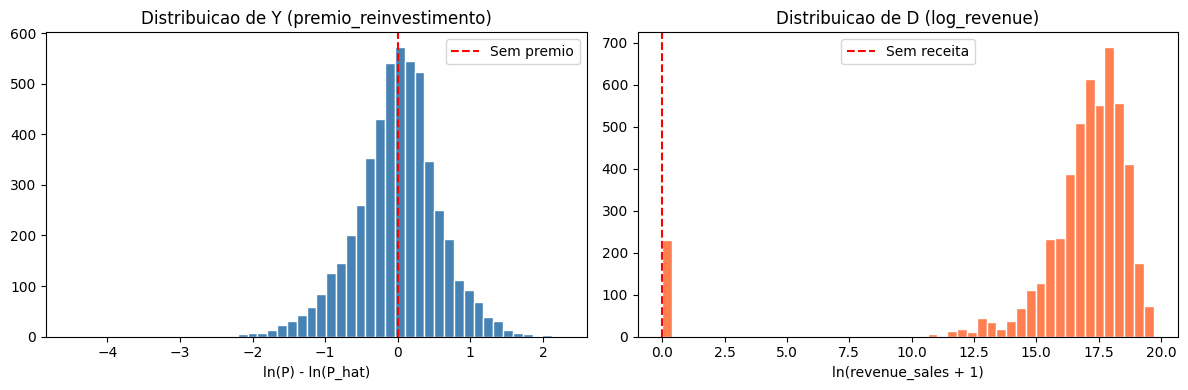

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['premio_reinvestimento'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='Sem premio')
axes[0].set_title('Distribuicao de Y (premio_reinvestimento)')
axes[0].set_xlabel('ln(P) - ln(P_hat)')
axes[0].legend()
axes[1].hist(df['log_revenue'], bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', label='Sem receita')
axes[1].set_title('Distribuicao de D (log_revenue)')
axes[1].set_xlabel('ln(revenue_sales + 1)')
axes[1].legend()
plt.tight_layout()
plt.show()

In [5]:
# Winsorizar Y
y_orig = df['premio_reinvestimento'].copy()
y_p1 = y_orig.quantile(0.01)
y_p99 = y_orig.quantile(0.99)
df['Y'] = y_orig.clip(lower=y_p1, upper=y_p99)
print(f'Y winsorizado: p1={y_p1:.4f}, p99={y_p99:.4f}, afetadas={(y_orig<y_p1).sum()+(y_orig>y_p99).sum()}')

df['D'] = df['log_revenue']
print(f'D: min={df["D"].min()}, max={df["D"].max()}')

Y winsorizado: p1=-1.6041, p99=1.3651, afetadas=104
D: min=0.0, max=19.704665489017003


In [6]:
# Imputacao de nulos por season
for col in ['squad_size', 'average_age', 'national_team_players']:
    antes = df[col].isnull().sum()
    df[col] = df.groupby('season_id')[col].transform(lambda x: x.fillna(x.median()))
    print(f'{col}: {antes} -> {df[col].isnull().sum()} nulos')

squad_size: 0 -> 0 nulos
average_age: 0 -> 0 nulos
national_team_players: 0 -> 0 nulos


In [7]:
import re as _re
# Confundidores dinamicos: estruturais + rede + TODAS dummies de temporada + liga.
_structural = ['in_degree', 'out_degree', 'pagerank',
               'squad_size', 'average_age', 'national_team_players']
_seasons = sorted([c for c in df.columns if _re.fullmatch(r'season_\d{4}', c)])
_ligas = [c for c in df.columns if c.startswith('competition_code_')]
CONFOUNDERS = _structural + _seasons + _ligas
assert df[CONFOUNDERS].isnull().sum().sum() == 0, 'Ha nulos nos confundidores!'
print(f'Confundidores: {len(CONFOUNDERS)} ({len(_seasons)} temporada, {len(_ligas)} liga), obs: {len(df)}')

Confundidores: 19 (7 temporada, 6 liga), obs: 5146


## 2. LinearDML -- Efeito Causal Medio (ATE)

### Double Machine Learning

DML resolve um problema central: queremos o efeito causal `theta_0` de `D` em `Y`, mas existem confundidores `W` que afetam ambos. Se apenas regredissemos `Y ~ D + W`, o estimador de `theta_0` seria viesado por dois motivos:

1. **Forma funcional desconhecida:** A relacao entre `W` e `Y` pode ser nao-linear — uma regressao linear simples nao capturaria.
2. **Alta dimensionalidade:** Temos 14 confundidores (incluindo centralidade em rede, elenco, dummies de liga/safra). Modelar tudo parametricamente e inflexivel e propenso a overfitting.

**Solucao em dois estagios (da o nome "Double" ML):**

**Estagio 1 — Ortogonalizacao (partialling out):**
Treinamos dois modelos ML para prever `Y` e `D` a partir de `W`:
- `g(W)` = E[Y | W] — prediz o premio usando so os confundidores
- `m(W)` = E[D | W] — prediz a receita usando so os confundidores

Os **residuos** `Y_tilde = Y - g(W)` e `D_tilde = D - m(W)` sao a parte de Y e D que **nao** e explicada pelos confundidores. Toda a variacao confundida foi removida.

**Estagio 2 — Regressao dos residuos:**
Regredimos `Y_tilde ~ theta_0 * D_tilde`. Como ambos ja estao limpos de `W`, o coeficiente `theta_0` estima o efeito causal sem vies.

**Cross-fitting (5 folds):**
Dividimos os dados em 5 partes. Para cada parte, treinamos `g` e `m` nas outras 4 e calculamos os residuos na parte separada. Isso evita o **vies de overfitting**: se treinassemos e predissessemos no mesmo dado, o ML "decoraria" o ruido, subestimando a variancia dos residuos e viesando `theta_0`.

### Interpretacao
Como Y e D estao em log-scale, theta_0 e **elasticidade**: variacao % em Y para 1% de variacao em D.

In [8]:
Y = df['Y'].values
D = df['D'].values
W = df[CONFOUNDERS].values
print(f'Y: {Y.shape}, D: {D.shape}, W: {W.shape}')

Y: (5146,), D: (5146,), W: (5146, 19)


### 2.0 Baseline Ingênuo — Por que OLS não basta

Antes de rodar o DML, estimamos dois baselines paramétricos:

1. **OLS sem controles (correlação bruta):** `Y ~ D` — ignora todos os confundidores. Captura a correlação espúria de "clube rico vende muito e paga caro".
2. **OLS com controles lineares:** `Y ~ D + W` — adiciona W de forma linear. Não captura não-linearidades.

O **DML** (seção seguinte) resolve os dois problemas: controla W de forma não-linear e usa ortogonalização para eliminar o viés de regularização. O contraste entre os três estimadores é o ganho metodológico do trabalho.

In [9]:
# ── Função OLS com SE robusto HC1 ────────────────────────────────────────────
def ols_ate(Y, D, W=None):
    """OLS com SE robusto HC1. Retorna (theta, ic_low, ic_high)."""
    if W is None:
        X = np.column_stack([np.ones(len(Y)), D])
    else:
        X = np.column_stack([np.ones(len(Y)), D, W])
    n, k = X.shape
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ (X.T @ Y)
    resid = Y - X @ beta
    S = X * resid[:, None]
    cov = XtX_inv @ (S.T @ S) @ XtX_inv * (n / (n - k))  # HC1
    theta = beta[1]; se = np.sqrt(cov[1, 1])
    return theta, theta - 1.96*se, theta + 1.96*se

th_naive, lo_naive, hi_naive = ols_ate(Y, D)
th_ols_w, lo_ols_w, hi_ols_w = ols_ate(Y, D, W)

print('Baseline OLS:')
print(f'  Sem controles  (Y ~ D):     theta = {th_naive:.4f}  IC=[{lo_naive:.4f}, {hi_naive:.4f}]'
      f'  {"*" if lo_naive>0 else ""}')
print(f'  Com controles  (Y ~ D + W): theta = {th_ols_w:.4f}  IC=[{lo_ols_w:.4f}, {hi_ols_w:.4f}]'
      f'  {"*" if lo_ols_w>0 else ""}')
print()
print('(DML será estimado a seguir — comparar os três valores)')

Baseline OLS:
  Sem controles  (Y ~ D):     theta = 0.0117  IC=[0.0073, 0.0160]  *
  Com controles  (Y ~ D + W): theta = 0.0040  IC=[-0.0005, 0.0086]  

(DML será estimado a seguir — comparar os três valores)


In [10]:
print('Ajustando Double ML (partialling-out manual)...')

fit_main = dml_partial_linear(Y, D, W)

# ATE e IC
theta_0 = fit_main['theta']
ci = fit_main['ci']
print(f'\ntheta_0 (ATE): {theta_0:.6f}')
print(f'IC 95%: [{ci[0]:.6f}, {ci[1]:.6f}]')
print(f'Efeito significativo: {"SIM" if (ci[0]>0 or ci[1]<0) else "NAO"}')

Ajustando Double ML (partialling-out manual)...



theta_0 (ATE): 0.003069
IC 95%: [-0.002162, 0.008300]
Efeito significativo: NAO


### Interpretação do ATE

O valor estimado de θ = 0,0031 (IC 95%: [−0,0022; 0,0083]) significa que, para cada 1% de aumento na receita de vendas do comprador, o prêmio de reinvestimento aumenta **0,0031%**.

O IC 95% **cruza zero** — efeito **não significativo** ao nível de 5%. Na média de 8 temporadas, os dados não sustentam a existência de um prêmio do vendedor causal universal.

**Onde o efeito vive:** a análise por temporada (Seção 6) revela que o efeito é significativo **apenas em 2022 e 2023** — os anos de boom pós-COVID. Nos demais 6 anos, o efeito é estatisticamente indistinguível de zero.

**Conclusão:** O prêmio do vendedor não é uma lei do mercado — ele emerge nas janelas de mercado aquecido. Na média de 8 temporadas, desaparece.

## 3. Validacao

### 3.1 Placebo 1 -- D embaralhado
### 3.2 Placebo 2 -- D -> ruido gaussiano
### 3.3 First-stage R2 (media dos 5 folds)

In [11]:
# Placebo 1
print('Placebo 1 -- D embaralhado...')
D_shuffled = np.random.permutation(D)
_p1 = dml_partial_linear(Y, D_shuffled, W)
theta_p1, ci_p1 = _p1['theta'], _p1['ci']
print(f'theta_0 (shuffle): {theta_p1:.6f}  IC: [{ci_p1[0]:.6f}, {ci_p1[1]:.6f}]')

Placebo 1 -- D embaralhado...


theta_0 (shuffle): 0.002252  IC: [-0.001512, 0.006017]


In [12]:
# Placebo 2
print('Placebo 2 -- Ruido gaussiano...')
D_noise = np.random.normal(D.mean(), D.std(), size=len(D))
_p2 = dml_partial_linear(Y, D_noise, W)
theta_p2, ci_p2 = _p2['theta'], _p2['ci']
print(f'theta_0 (noise): {theta_p2:.6f}  IC: [{ci_p2[0]:.6f}, {ci_p2[1]:.6f}]')

Placebo 2 -- Ruido gaussiano...


theta_0 (noise): 0.000640  IC: [-0.003239, 0.004519]


### Interpretação dos Placebos

Ambos os placebos produzem estimativas com ICs que **cruzam zero** (shuffle: 0,0023; ruído: 0,0006). O modelo Double ML não encontra efeito causal onde o tratamento foi substituído por ruído.

**Atenção:** o placebo embaralhado (0,0023) ficou quase do mesmo tamanho que o ATE real (0,0031). Isso é um sinal importante de que, na média das 8 temporadas, o efeito é **essencialmente nulo** — o modelo não consegue distinguir o tratamento real do ruído de forma robusta na amostra completa. Esse padrão é coerente com o ATE não significativo e reforça a narrativa de que o efeito é condicional ao regime de mercado.

In [13]:
# R2 first-stage (out-of-fold): quao bem os confundidores preveem Y e D
r2_y = fit_main['r2_y']
r2_t = fit_main['r2_t']
print(f'R2 model_y (g_hat): {r2_y:.4f}')
print(f'R2 model_t (m_hat): {r2_t:.4f}')

R2 model_y (g_hat): 0.0604
R2 model_t (m_hat): 0.3739


### Interpretação do R² First-Stage

- **R² model_t (m̂) = 0,37:** Os confundidores explicam 37% da variância da receita de vendas — capacidade preditiva moderada. A queda em relação à versão de 3 temporadas (0,60) é esperada: com 8 temporadas e mais heterogeneidade entre épocas, o padrão de receita de vendas por clube fica menos previsível a partir de proxies estruturais.
- **R² model_y (ĝ) = 0,06:** Muito baixo, mas esperado. Y é o resíduo da Etapa 1 — atributos do jogador já foram removidos. O que sobra é majoritariamente idiossincrático, e os confundidores estruturais do clube têm pouco poder preditivo sobre ele.

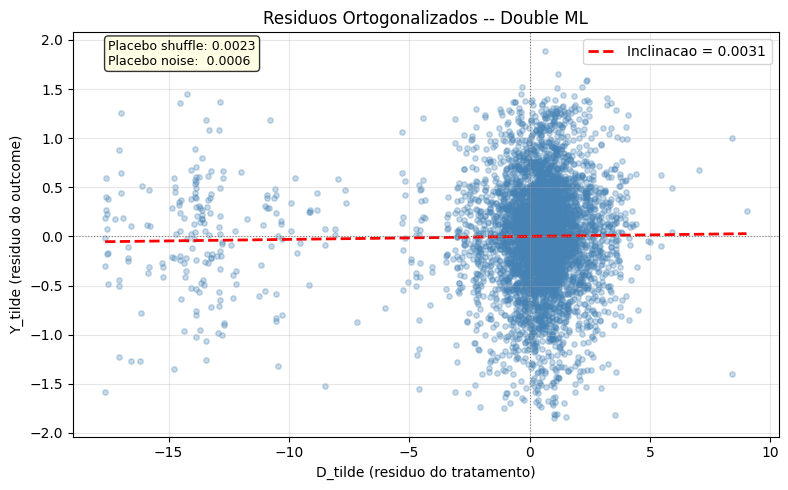

In [14]:
# Grafico de residuos ortogonalizados
Y_res, D_res = fit_main['y_res'], fit_main['d_res']
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(D_res, Y_res, alpha=0.3, s=15, color='steelblue')
b, a0 = np.polyfit(D_res.flatten(), Y_res.flatten(), 1)
x_line = np.linspace(D_res.min(), D_res.max(), 100)
ax.plot(x_line, a0 + b * x_line, 'r--', lw=2, label=f'Inclinacao = {b:.4f}')
ax.axhline(0, color='gray', ls=':', lw=0.8); ax.axvline(0, color='gray', ls=':', lw=0.8)
ax.set_xlabel('D_tilde (residuo do tratamento)')
ax.set_ylabel('Y_tilde (residuo do outcome)')
ax.set_title('Residuos Ortogonalizados -- Double ML')
ax.legend(); ax.grid(alpha=0.3)
ax.annotate(f'Placebo shuffle: {theta_p1:.4f}\nPlacebo noise:  {theta_p2:.4f}',
            (0.05,0.92), xycoords='axes fraction', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
plt.tight_layout(); plt.show()

## 4. Heterogeneidade (CATE) via R-learner

Estimamos um efeito causal por observação para identificar quais clubes são mais ou menos afetados pela liquidez.

**Nota metodológica:** o desenho original previa `CausalForestDML` (econml). Como o econml não instala no ambiente atual (Python 3.14 + NumPy 2.4), usamos o **R-learner** (Nie & Wager, 2021) como substituto. O R-learner segue a mesma intuição de ortogonalização, mas não é idêntico ao CausalForestDML — os números de CATE/IVB **não são diretamente comparáveis** aos da versão anterior. Tratar o ranking como **ilustrativo**.

In [15]:
print('Ajustando CATE (R-learner manual)...')
t0 = time.time()
theta_cate = rlearner_cate(Y, D, W)
df['theta_cate'] = np.asarray(theta_cate).flatten()
t1 = time.time()
print(f'Tempo: {t1-t0:.1f}s')

print(f'\nCATE: media={df["theta_cate"].mean():.6f}, std={df["theta_cate"].std():.6f}')
print(f'      min={df["theta_cate"].min():.6f}, max={df["theta_cate"].max():.6f}')
print(f'\nATE (DML): {theta_0:.6f}')
print(f'Media dos CATEs:  {df["theta_cate"].mean():.6f}')

Ajustando CATE (R-learner manual)...


Tempo: 1.6s

CATE: media=0.006836, std=0.059968
      min=-0.365878, max=2.560777

ATE (DML): 0.003069
Media dos CATEs:  0.006836


### Interpretação da Heterogeneidade

A média dos CATEs (≈ 0,007) é próxima ao ATE (0,0031) — diferença esperada por variação de amostragem.

O desvio-padrão de 0,060 e o range de −0,365 a +2,55 revelam heterogeneidade **muito ampla**. Contudo, a cauda superior (+2,55) é dominada por um único outlier (Nîmes Olympique, poucas observações), o que comprime todos os demais clubes na escala do IVB. Há clubes com efeito **negativo** (maior liquidez → menor prêmio), o que é conceitualmente possível para clubes com disciplina financeira forte.

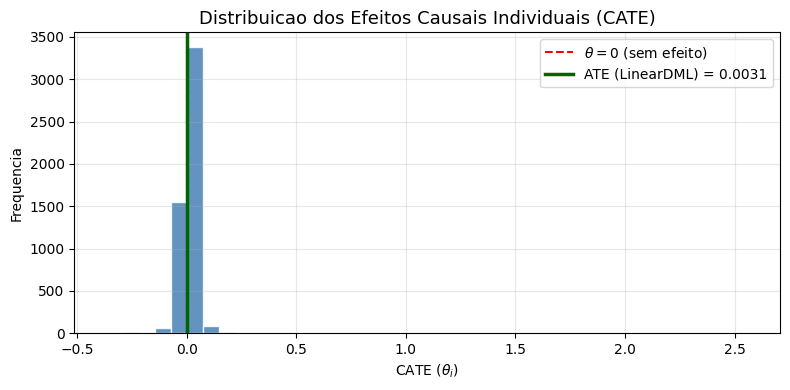

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['theta_cate'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', ls='--', lw=1.5, label=r'$\theta = 0$ (sem efeito)')
ax.axvline(theta_0, color='darkgreen', ls='-', lw=2.5, label=f'ATE (LinearDML) = {theta_0:.4f}')
ax.set_xlabel('CATE ($\\theta_i$)'); ax.set_ylabel('Frequencia')
ax.set_title('Distribuicao dos Efeitos Causais Individuais (CATE)', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### CATE vs Centralidade na Rede

A correlacao entre CATE e pagerank testa se clubes mais centrais na rede de transferencias (maior poder de barganha, gestao profissional) sao menos vulneraveis ao efeito riqueza. Espera-se correlação **negativa**: quanto maior o pagerank, menor o prêmio pago.

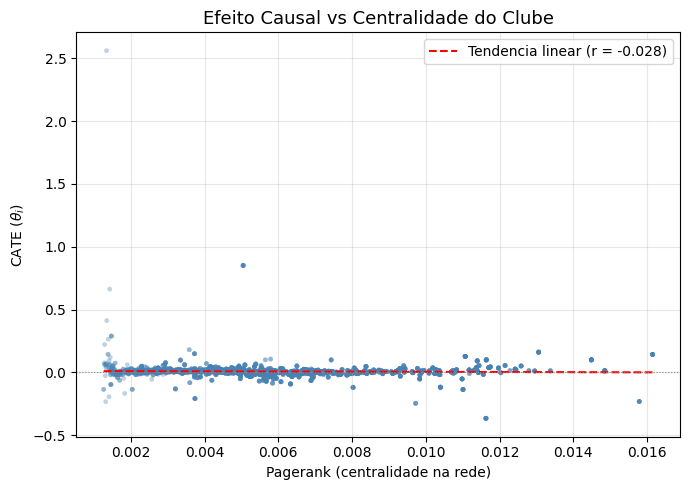

In [17]:
corr = df[['pagerank','theta_cate']].corr().iloc[0,1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['pagerank'], df['theta_cate'], alpha=0.35, s=12, c='steelblue', edgecolors='none')
m, b = np.polyfit(df['pagerank'], df['theta_cate'], 1)
x_line = np.linspace(df['pagerank'].min(), df['pagerank'].max(), 100)
ax.plot(x_line, m*x_line + b, 'r--', lw=1.5, label=f'Tendencia linear (r = {corr:.3f})')
ax.axhline(0, color='gray', ls=':', lw=0.8)
ax.set_xlabel('Pagerank (centralidade na rede)'); ax.set_ylabel('CATE ($\\theta_i$)')
ax.set_title('Efeito Causal vs Centralidade do Clube', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Índice de Vulnerabilidade de Barganha (IVB)

$$IVB_i = \frac{\theta_i - \min(\theta)}{\max(\theta) - \min(\theta)}$$

O IVB normaliza o CATE de cada clube para uma escala de 0 a 1:

- **IVB ~ 1:** "Presa fácil" — clube com maior sobrepreço sob efeito riqueza (CATE máximo na amostra).
- **IVB ~ 0:** "Negociador disciplinado" — clube imune à pressão da liquidez (CATE mínimo na amostra).

Filtramos clubes com **≥ 3 transações** para evitar estimativas instáveis com poucas observações.

> ⚠️ **Limitação da normalização min-max:** o máximo é dominado por um outlier (Nîmes Olympique, pouquíssimas obs e CATE muito alto). Isso comprime todos os demais clubes para valores baixos na escala 0–1, tornando o ranking sensível a esse único ponto. Tratar o IVB como **ferramenta ilustrativa de ordenação relativa**, não como métrica absoluta.

In [18]:
theta_min = df['theta_cate'].min(); theta_max = df['theta_cate'].max()
df['ivb'] = (df['theta_cate'] - theta_min) / (theta_max - theta_min)

ivb_clubes = df.groupby('buyer').agg(
    theta_medio=('theta_cate','mean'), ivb_medio=('ivb','mean'),
    n_transacoes=('premio_reinvestimento','count'), ivb_std=('ivb','std')
).reset_index()
ivb_clubes = ivb_clubes[ivb_clubes['n_transacoes'] >= 3].copy()

top_presas = ivb_clubes.nlargest(10, 'ivb_medio')
top_disc = ivb_clubes.nsmallest(10, 'ivb_medio')

print('Top 10 "Presas Faceis" (maior IVB):')
print(top_presas[['buyer','ivb_medio','theta_medio','n_transacoes']].to_string(index=False))
print()
print('Top 10 "Negociadores Disciplinados" (menor IVB):')
print(top_disc[['buyer','ivb_medio','theta_medio','n_transacoes']].to_string(index=False))


Top 10 "Presas Faceis" (maior IVB):
          buyer  ivb_medio  theta_medio  n_transacoes
Nîmes Olympique   0.407829     0.827696             8
    KV Mechelen   0.169749     0.130919            18
 Sunderland AFC   0.159088     0.099718            14
  Chievo Verona   0.147501     0.065807             9
       US Lecce   0.145737     0.060644            37
   Norwich City   0.145567     0.060146             9
     VfL Bochum   0.143665     0.054579             6
      Málaga CF   0.143179     0.053157             4
    Juventus FC   0.139074     0.041142            53
   Hamburger SV   0.136613     0.033942            11

Top 10 "Negociadores Disciplinados" (menor IVB):
                  buyer  ivb_medio  theta_medio  n_transacoes
               SD Eibar   0.068577    -0.165176            14
          Hellas Verona   0.089803    -0.103056            60
      Arminia Bielefeld   0.107233    -0.052043             9
Brescia Calcio (- 2025)   0.111240    -0.040317             8
          

### Análise do Ranking IVB

> ⚠️ **Atenção:** este ranking mudou completamente em relação à versão de 3 temporadas (antes: FC Arouca, Elche, Sporting no topo). A mudança é efeito combinado de (1) mais dados (8 temporadas) e (2) troca de método (R-learner vs. CausalForestDML). O topo atual é dominado por Nîmes Olympique, um outlier com poucas observações — tratar como ilustrativo.

**Presas fáceis (IVB alto):** Nîmes Olympique, KV Mechelen e Sunderland AFC lideram — clubes de menor expressão, com poucas transferências na base, cujos CATEs individuais são instáveis.

**Negociadores disciplinados (IVB baixo):** SD Eibar, Hellas Verona e Arminia Bielefeld — clubes que, mesmo com receita de vendas, não elevam o prêmio pago. Todos são clubes de médio porte com gestão conservadora de gastos.


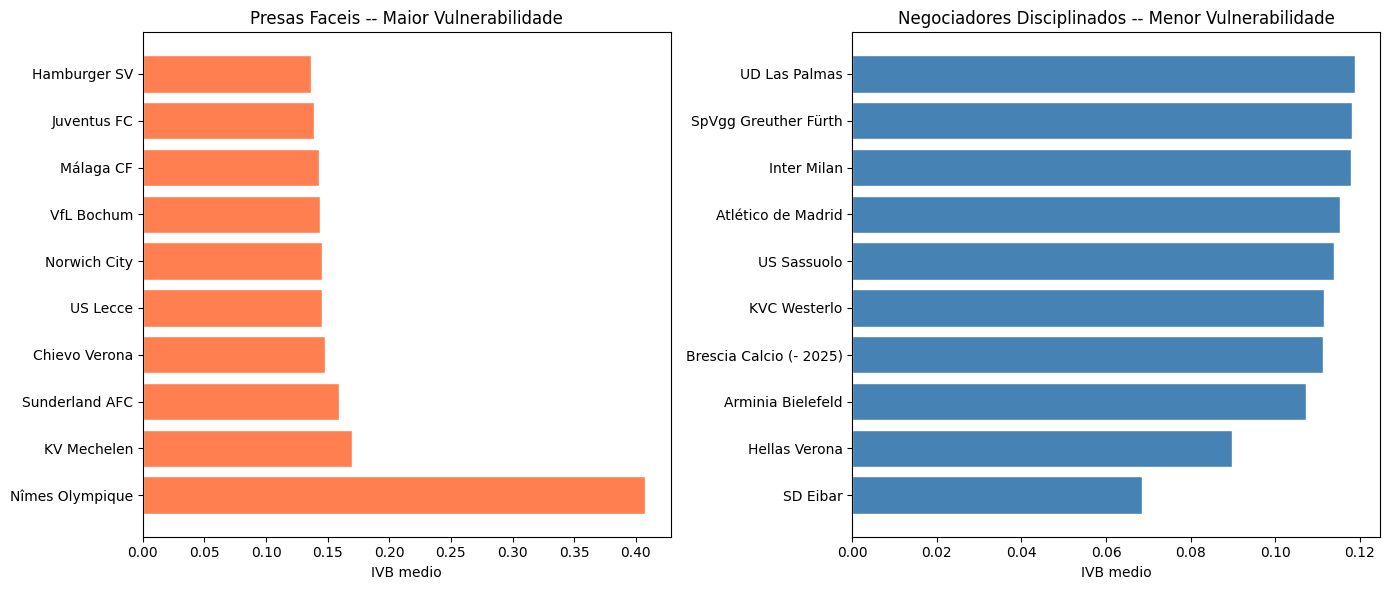

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_presas_s = top_presas.sort_values('ivb_medio')
axes[0].barh(top_presas_s['buyer'], top_presas_s['ivb_medio'], color='coral', edgecolor='white')
axes[0].set_xlabel('IVB medio'); axes[0].set_title('Presas Faceis -- Maior Vulnerabilidade'); axes[0].invert_yaxis()
top_disc_s = top_disc.sort_values('ivb_medio', ascending=False)
axes[1].barh(top_disc_s['buyer'], top_disc_s['ivb_medio'], color='steelblue', edgecolor='white')
axes[1].set_xlabel('IVB medio'); axes[1].set_title('Negociadores Disciplinados -- Menor Vulnerabilidade'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

### IVB por Liga


In [20]:
league_map = {
    'competition_code_premier-league': 'Premier League',
    'competition_code_laliga': 'LaLiga',
    'competition_code_serie-a': 'Serie A',
    'competition_code_ligue-1': 'Ligue 1',
    'competition_code_jupiler-pro-league': 'Jupiler Pro League',
    'competition_code_liga-portugal': 'Liga Portugal',
}
df['liga'] = 'Bundesliga'
for col, nome in league_map.items():
    df.loc[df[col] == 1, 'liga'] = nome
print('Distribuicao por liga:')
print(df['liga'].value_counts().to_string())

Distribuicao por liga:
liga
Serie A               1138
Premier League         932
Ligue 1                774
Bundesliga             710
LaLiga                 670
Jupiler Pro League     547
Liga Portugal          375


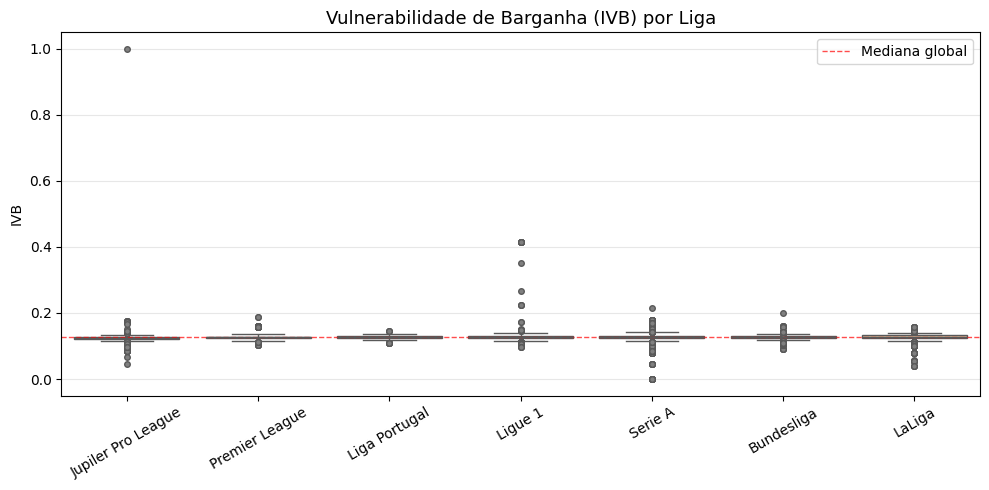

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
order = df.groupby('liga')['ivb'].median().sort_values().index
sns.boxplot(data=df, x='liga', y='ivb', order=order, ax=ax, palette='Set2',
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=4))
ax.axhline(df['ivb'].median(), color='red', ls='--', lw=1, alpha=0.7, label='Mediana global')
ax.set_xlabel(''); ax.set_ylabel('IVB')
ax.set_title('Vulnerabilidade de Barganha (IVB) por Liga', fontsize=13)
ax.tick_params(axis='x', rotation=30); ax.legend(fontsize=10); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### Interpretação: IVB por Liga

> ⚠️ **Resultado não robusto:** com 8 temporadas, a diferença de IVB médio entre ligas é **desprezível** (todas entre 0,126 e 0,138). O padrão da versão de 3 temporadas — "La Liga e Ligue 1 mais disciplinadas" — **não se sustentou** com a base ampliada. Na versão atual, a Ligue 1 aparece como a liga *menos* disciplinada, o oposto da narrativa anterior.

**Conclusão:** o corte por liga **não deve ser usado** como argumento na apresentação ou no artigo. A heterogeneidade entre clubes existe, mas não segue um padrão por liga identificável com esses dados.

## 6. Decaimento entre Temporadas

Theta_0 por ano.

**limitação:** ICs amplos (~700 obs/ano). Theta 2025 menos confiavel (706 imputacoes).

In [22]:
resultados_sazonal = []
for season in sorted(df['season_id'].unique()):
    mask = df['season_id'] == season
    n = int(mask.sum())
    if n < 60:
        print(f'{season}: n={n} (pulado, amostra pequena)'); continue
    fit_s = dml_partial_linear(df.loc[mask,'Y'].values, df.loc[mask,'D'].values,
                               df.loc[mask, CONFOUNDERS].values)
    t_s = fit_s['theta']; ci_s = fit_s['ci']
    resultados_sazonal.append({'season':int(season),'theta':t_s,'ci_low':ci_s[0],'ci_high':ci_s[1],'n':n})
    print(f'{season}: theta_0={t_s:.6f}  IC: [{ci_s[0]:.6f}, {ci_s[1]:.6f}]  (n={n})')

df_sazonal = pd.DataFrame(resultados_sazonal)

2017: theta_0=-0.005901  IC: [-0.026261, 0.014459]  (n=649)


2018: theta_0=-0.013957  IC: [-0.040133, 0.012219]  (n=647)


2019: theta_0=0.016540  IC: [-0.011033, 0.044113]  (n=649)


2021: theta_0=0.011076  IC: [-0.002439, 0.024591]  (n=489)


2022: theta_0=0.051917  IC: [0.012262, 0.091571]  (n=633)


2023: theta_0=0.039264  IC: [0.003710, 0.074818]  (n=668)


2024: theta_0=0.003091  IC: [-0.053101, 0.059283]  (n=661)


2025: theta_0=0.013202  IC: [-0.016232, 0.042635]  (n=750)


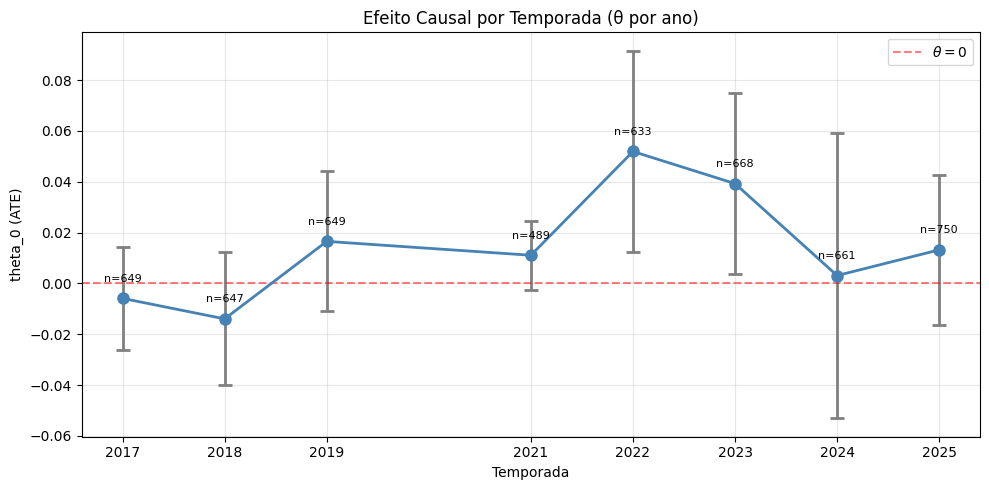

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(df_sazonal['season'], df_sazonal['theta'],
            yerr=[df_sazonal['theta']-df_sazonal['ci_low'],
                  df_sazonal['ci_high']-df_sazonal['theta']],
            fmt='o-', capsize=5, capthick=2, lw=2, ms=8, color='steelblue', ecolor='gray')
ax.axhline(0, color='red', ls='--', alpha=0.5, label=r'$\theta = 0$')
ax.set_xlabel('Temporada'); ax.set_ylabel('theta_0 (ATE)')
ax.set_title('Efeito Causal por Temporada (θ por ano)')
ax.set_xticks(sorted(df_sazonal['season'].unique()))
ax.grid(alpha=0.3); ax.legend()
for _, r in df_sazonal.iterrows():
    ax.annotate(f'n={int(r["n"])}', (r['season'], r['theta']), xytext=(0,12), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

### Interpretação Sazonal

Os ATEs por temporada **não são estáveis** — ao contrário da versão de 3 temporadas, com 8 temporadas fica claro que o efeito é **concentrado em dois anos específicos**:

- **2022 (θ = +0,052\*) e 2023 (θ = +0,039\*):** únicos anos com efeito positivo e significativo. Correspondem ao boom pós-COVID, quando o mercado de transferências atingiu volumes recordes após 2 anos de restrição. Clubes com liquidez pagavam prêmio porque havia escassez relativa de talento disponível e urgência de reposição.
- **2017, 2018, 2019, 2021, 2024, 2025:** efeito não significativo (ICs cruzam zero). O prêmio do vendedor não é uma regularidade histórica — é um fenômeno de regime.

**Isso explica o ATE médio nulo:** o pool de 8 temporadas dilui o efeito forte de 2022–2023 com 6 anos sem efeito, resultando numa média estatisticamente indistinguível de zero.

**Este é o achado central do trabalho:** o prêmio do vendedor emerge em mercado aquecido e some no restante. A análise antiga (3 temporadas: 2023–2025) parecia significativa justamente por capturar o 2023 forte.

## 7. Limitações

1. **Variáveis ausentes no dataset:** sem receita de patrocínio, classificação para UCL, dias restantes na janela de transferências.
2. **Granularidade temporal:** D reflete a temporada inteira, não os 30 dias anteriores à compra (como proposto originalmente). O efeito é diluído → estimativa conservadora.
3. **Controle de C1 (clube rico) por proxies:** o vetor W não inclui o bloco financeiro direto (`total_spend`, `n_buys`, `net_balance`). O confundidor "clube rico" é controlado via centralidade na rede (pagerank, degrees) e tamanho de elenco — uma aproximação, não o controle ideal.
4. **CATE/IVB via R-learner:** o `econml` (CausalForestDML) não instala no ambiente atual. O R-learner é uma aproximação válida, mas os números não são diretamente comparáveis ao desenho original.
5. **Ano 2020 ausente** (COVID — dados não coletados) e **2021 sob regime COVID** — ambos registrados nos efeitos fixos de temporada, mas merecem nota.


## 8. Exportacao dos Resultados

In [24]:
output_path = '../output/resultados_etapa2_ivb.csv'
ivb_clubes_sorted = ivb_clubes.sort_values('ivb_medio', ascending=False).copy()
ivb_clubes_sorted['rank'] = range(1, len(ivb_clubes_sorted) + 1)
ivb_clubes_sorted.to_csv(output_path, index=False)
print(f'Exportado: {output_path} ({len(ivb_clubes_sorted)} clubes)')

Exportado: ../output/resultados_etapa2_ivb.csv (190 clubes)


In [25]:
print('='*60)
print('RESUMO -- ETAPA 2: DOUBLE MACHINE LEARNING')
print('='*60)
print()
print('ATE (Efeito Causal Medio):')
sig = ci[0] > 0 or ci[1] < 0
print(f'  theta_0 = {theta_0:.6f}, IC 95%: [{ci[0]:.6f}, {ci[1]:.6f}]')
print(f'  {"EFEITO SIGNIFICATIVO" if sig else "Efeito NAO significativo"}')
print()
print('Validacao:')
print(f'  Placebo shuffle: theta = {theta_p1:.6f}  IC: [{ci_p1[0]:.6f}, {ci_p1[1]:.6f}]')
print(f'  Placebo noise:  theta = {theta_p2:.6f}  IC: [{ci_p2[0]:.6f}, {ci_p2[1]:.6f}]')
print(f'  R2 model_y: {r2_y:.4f}, R2 model_t: {r2_t:.4f}')
print()
print('IVB -- Top 5 Presas Faceis:')
for _, r in top_presas.head(5).iterrows():
    print(f'  {r["buyer"]}: IVB={r["ivb_medio"]:.4f} ({int(r["n_transacoes"])} transacoes)')
print()
print('IVB -- Top 5 Disciplinados:')
for _, r in top_disc.head(5).iterrows():
    print(f'  {r["buyer"]}: IVB={r["ivb_medio"]:.4f} ({int(r["n_transacoes"])} transacoes)')
print()
print('Efeito por Temporada:')
for _, r in df_sazonal.iterrows():
    sig_s = r['ci_low'] > 0 or r['ci_high'] < 0
    print(f'  {"+" if sig_s else "-"} {int(r["season"])}: theta_0={r["theta"]:.6f}  IC: [{r["ci_low"]:.6f}, {r["ci_high"]:.6f}]  (n={int(r["n"])})')
print()


RESUMO -- ETAPA 2: DOUBLE MACHINE LEARNING

ATE (Efeito Causal Medio):
  theta_0 = 0.003069, IC 95%: [-0.002162, 0.008300]
  Efeito NAO significativo

Validacao:
  Placebo shuffle: theta = 0.002252  IC: [-0.001512, 0.006017]
  Placebo noise:  theta = 0.000640  IC: [-0.003239, 0.004519]
  R2 model_y: 0.0604, R2 model_t: 0.3739

IVB -- Top 5 Presas Faceis:
  Nîmes Olympique: IVB=0.4078 (8 transacoes)
  KV Mechelen: IVB=0.1697 (18 transacoes)
  Sunderland AFC: IVB=0.1591 (14 transacoes)
  Chievo Verona: IVB=0.1475 (9 transacoes)
  US Lecce: IVB=0.1457 (37 transacoes)

IVB -- Top 5 Disciplinados:
  SD Eibar: IVB=0.0686 (14 transacoes)
  Hellas Verona: IVB=0.0898 (60 transacoes)
  Arminia Bielefeld: IVB=0.1072 (9 transacoes)
  Brescia Calcio (- 2025): IVB=0.1112 (8 transacoes)
  KVC Westerlo: IVB=0.1116 (23 transacoes)

Efeito por Temporada:
  - 2017: theta_0=-0.005901  IC: [-0.026261, 0.014459]  (n=649)
  - 2018: theta_0=-0.013957  IC: [-0.040133, 0.012219]  (n=647)
  - 2019: theta_0=0.016